In [3]:
import numpy as np
import matplotlib.pyplot as plt

**Question 5, part a**

In [6]:
import hh_sim as hh

Sustained firing occurs at Id = 7 and produces 11 spikes. Repetitive sustained firing is defined as just below 50% of the way to this level of sustained firing, so that is 6 spikes. A current is considered to be enough to cause repetiive sustained firing if it causes at least 6 spikes. Skipfrac was kept the same at 40%.

In [9]:
def is_rep(I):
    t, V, spk, rate = hh.hh_sim(I)
    return len(spk) >=6

In [11]:
tol = 1e-6
I_h = 7
I_l = 6

while abs(I_h - I_l) > tol:

    mid = (I_l + I_h) / 2
    if is_rep(mid):
        I_h = mid
    else:
        I_l = mid

In [12]:
I_rheo = (I_l + I_h) / 2
I_rheo

6.260440349578857

In [13]:
I_rheo =round(I_rheo,3)
I_rheo

6.26

In [14]:
tb, Vb, spkb, rateb = hh.hh_sim(I_rheo-0.001)
ta, Va, spka, ratea = hh.hh_sim(I_rheo+0.001)

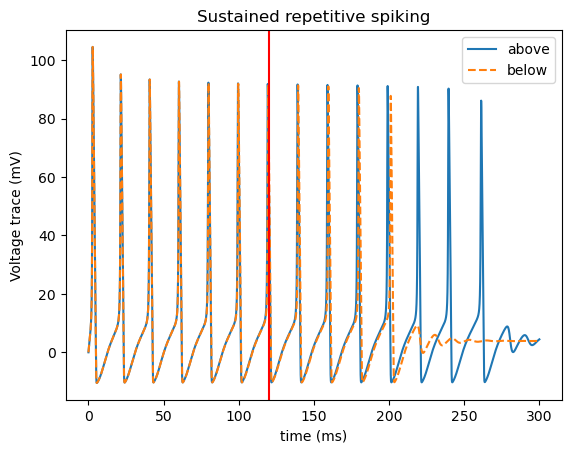

In [15]:
plt.plot(ta,Va,label = 'above')
plt.plot(tb,Vb,label = 'below',linestyle='--')
plt.axvline(120,color='red')
plt.xlabel('time (ms)')
plt.ylabel('Voltage trace (mV)')
plt.title('Sustained repetitive spiking')
plt.legend()
plt.show()

The spikes in the first 120 ms are ignored because the skipfrac is 40%. 40% of 300 ms (tmax) is 120 ms.

**Question 5, part b**

Compute the firing rate at a sequence of currents from just above rheobase up to roughly twice it, plot
the f–I curve, and report the onset rate to three digits. Does the rate rise continuously from zero, or switch
on at a nonzero value? Which of the two bifurcation scenarios from problems 2 and 3 does Hodgkin-Huxley
resemble, and what is the physiological consequence?

In [24]:
curr_seq = np.linspace(I_rheo,2*I_rheo)
curr_seq

array([ 6.26      ,  6.3877551 ,  6.5155102 ,  6.64326531,  6.77102041,
        6.89877551,  7.02653061,  7.15428571,  7.28204082,  7.40979592,
        7.53755102,  7.66530612,  7.79306122,  7.92081633,  8.04857143,
        8.17632653,  8.30408163,  8.43183673,  8.55959184,  8.68734694,
        8.81510204,  8.94285714,  9.07061224,  9.19836735,  9.32612245,
        9.45387755,  9.58163265,  9.70938776,  9.83714286,  9.96489796,
       10.09265306, 10.22040816, 10.34816327, 10.47591837, 10.60367347,
       10.73142857, 10.85918367, 10.98693878, 11.11469388, 11.24244898,
       11.37020408, 11.49795918, 11.62571429, 11.75346939, 11.88122449,
       12.00897959, 12.13673469, 12.2644898 , 12.3922449 , 12.52      ])

In [26]:
rate_list = []
for c in curr_seq:
    t, V, spk, rate = hh.hh_sim(c)
    rate_list.append(rate)

rate_arr = np.array(rate_list)

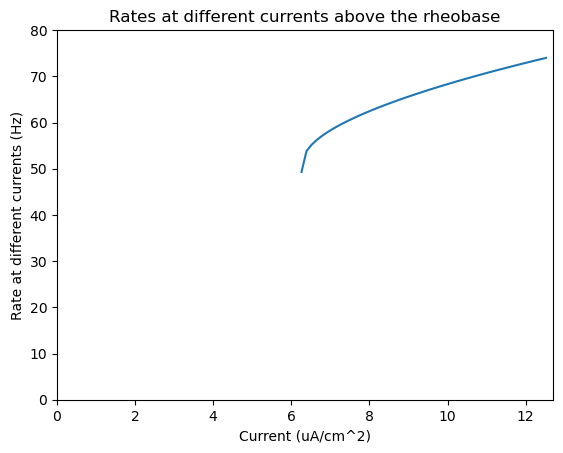

In [27]:
plt.plot(curr_seq,rate_arr)
plt.xlim(0, 12.70)
plt.title('Rates at different currents above the rheobase')
plt.xlabel('Current (uA/cm^2)')
plt.ylabel('Rate at different currents (Hz)')
plt.ylim(0, 80)
plt.show()

In [28]:
onset_rate = rate_arr[0]
onset_rate

49.29143561306223

The rate switches on at a nonzero value, and this represents the FitzHugh-Nagumo model (question 2). The physiological consequence is that it suggests that neurons won't fire at all unless there is some mimumum level of input provided.

**Question 5, part c**

Change gK from 36 to 30 (mS/cm2) and recompute the rheobase by the same bisection. Report both
rheobase values to three digits in a small table, and overlay the two f–I curves on a single set of axes with
the two rheobase values marked. Did the rheobase go up or down? Explain the result in terms of the currents
in the model, and say whether the shape of the curve changed or only its position

In [29]:
def is_rep_30(I):
    t, V, spk, rate = hh.hh_sim(I,gK=30)
    return len(spk) >=6

In [30]:
tol = 1e-6
I_h30 = 7
I_l30 = 6

while abs(I_h30 - I_l30) > tol:

    mid30 = (I_l30 + I_h30) / 2
    if is_rep_30(mid30):
        I_h30 = mid30
    else:
        I_l30 = mid30

In [31]:
I_rheo30 = (I_l30 + I_h30) / 2
I_rheo30

6.000000476837158

In [32]:
I_rheo30 = round(I_rheo30,3)
I_rheo30

6.0

|  | I_rheo | I_rheo30 |
|----------|----------|----------|
|     | 6.260     | 6.000     |

In [34]:
curr_seq30 = np.linspace(I_rheo30,2*I_rheo30)

rate_list30 = []
for c in curr_seq30:
    t, V, spk, rate = hh.hh_sim(c)
    rate_list30.append(rate)

rate_arr30 = np.array(rate_list30)

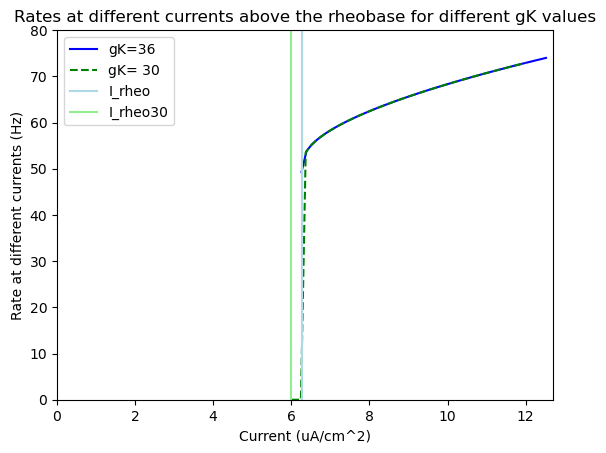

In [35]:
plt.plot(curr_seq,rate_arr,label = 'gK=36',color='blue')
plt.plot(curr_seq30,rate_arr30,label='gK= 30',color='green',linestyle='--')
plt.axvline(6.260,color='lightblue',label='I_rheo')
plt.axvline(6.000,color= 'lightgreen',label='I_rheo30')
plt.xlim(0, 12.70)
plt.ylim(0, 80)
plt.xlabel('Current (uA/cm^2)')
plt.ylabel('Rate at different currents (Hz)')
plt.title('Rates at different currents above the rheobase for different gK values')
plt.legend()
plt.show()

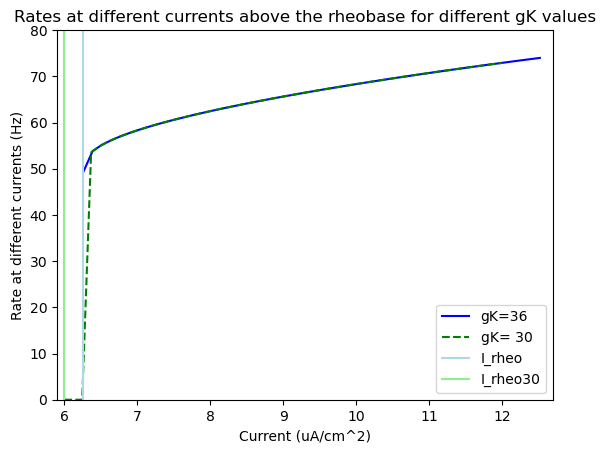

In [36]:
plt.plot(curr_seq,rate_arr,label = 'gK=36',color='blue')
plt.plot(curr_seq30,rate_arr30,label='gK= 30',color='green',linestyle='--')
plt.axvline(6.260,color='lightblue',label='I_rheo')
plt.axvline(6.000,color= 'lightgreen',label='I_rheo30')
plt.xlim(5.9, 12.70)
plt.ylim(0, 80)
plt.xlabel('Current (uA/cm^2)')
plt.ylabel('Rate at different currents (Hz)')
plt.title('Rates at different currents above the rheobase for different gK values')
plt.legend()
plt.show()

The rheobase went down as gK went down. When gK decreases, the maximal conductance of potassium is decreased, so the neuron is less negative at its resting value. This makes it need less current/positive voltage to fire. This is why I_rheo30 is less than I_rheo. The shape of the curve to the right is the same, but the gK=30 curve decreases gradually to around I_rheo and then goes to 0 for the same reason. The shape of the curve changed. It can be seen that the critical curent is the same on both curves because the value the neuron needs to fire won't change based on the max potassium conductance.